In [14]:
import os
import argparse
import logging
from ast import literal_eval  # para evaluar cadenas que contienen listas literales

import numpy as np
import pandas as pd
import time
# Importamos utilidades de scikit-learn para preprocesamiento, reducción y clustering
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración básica del logger para imprimir progreso
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

# Directorio donde guardamos salidas (crea si no existe)
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [15]:
def extract_primary_genre(genres_field):
    """Extrae el primer género de una columna que puede ser:
    - NaN
    - una lista de Python (ej. ['Action','Adventure']) serializada como string
    - una cadena separada por comas ('Action, Adventure')

    Devuelve None (np.nan) si no hay género.
    """
    # Si es NaN devolvemos NaN
    if pd.isna(genres_field):
        return np.nan
    # Si ya es una lista Python en memoria, tomar el primer elemento
    if isinstance(genres_field, list):
        return genres_field[0] if len(genres_field) > 0 else np.nan
    # Convertir a string y limpiar espacios
    s = str(genres_field).strip()
    # Intentar interpretar cadenas que contienen una lista literal (p. ej. "['A','B']")
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
            return parsed[0]
    except Exception:
        # Si falla, seguimos con el fallback
        pass
    # Si tiene comas, asumimos formato 'A, B, C' y tomamos el primero
    if ',' in s:
        return s.split(',')[0].strip().strip("'\"")
    # En cualquier otro caso devolvemos el string limpio
    return s.strip().strip("'\"")

def cluster_purity(labels_true, labels_pred):
    """Calcula la pureza de clusters (proporción de elementos correctamente asignados
    si usamos la etiqueta más frecuente de cada cluster).

    labels_true: array-like de etiquetas verdaderas (single-label por fila)
    labels_pred: etiquetas de cluster producidas por el algoritmo
    """
    # Creamos un DataFrame temporal para agrupar
    dfc = pd.DataFrame({'true': labels_true, 'pred': labels_pred})
    # Rellenar predictores nulos con -1 (ruido) para contar adecuadamente
    dfc['pred'] = dfc['pred'].fillna(-1)
    total = len(dfc)
    if total == 0:
        return np.nan
    pur_sum = 0
    # Para cada cluster, sumar el número de elementos de la clase mayoritaria
    for c in dfc['pred'].unique():
        sub = dfc[dfc['pred'] == c]
        if len(sub) == 0:
            continue
        top = sub['true'].value_counts().iloc[0]
        pur_sum += top
    # Dividir por el total para obtener la pureza global
    return pur_sum / total

In [16]:
def load_and_merge(animes_path='animes.csv', dataset_path='dataset_completo.csv', ratings_path='ratings.csv'):
    """Carga `animes.csv` y `dataset_completo.csv`, los une y agrega estadísticas de `ratings.csv`.

    ratings.csv se procesa por chunks para no cargar todo en memoria cuando es grande.
    """
    # Cargar archivo de animes
    logging.info('Cargando animes desde %s', animes_path)
    animes = pd.read_csv(animes_path)
    logging.info('animes shape: %s', animes.shape)

    # Cargar dataset adicional con sinopsis/genres API
    logging.info('Cargando dataset_completo desde %s', dataset_path)
    ds = pd.read_csv(dataset_path)
    logging.info('dataset_completo shape: %s', ds.shape)

    # Intentar hacer merge por `animeID`; si no existe, intentamos por `title`
    if 'animeID' in animes.columns and 'animeID' in ds.columns:
        merged = pd.merge(animes, ds, on='animeID', how='outer', suffixes=('_anime','_ds'))
    else:
        merged = pd.merge(animes, ds, on='title', how='outer', suffixes=('_anime','_ds'))
    logging.info('Merged shape: %s', merged.shape)

    # Si existe ratings.csv lo procesamos en chunks
    if os.path.exists(ratings_path):
        logging.info('Procesando ratings desde %s (chunksize)...', ratings_path)
        # Intentar leer sólo el header para conocer columnas
        try:
            header = pd.read_csv(ratings_path, nrows=0)
            cols = list(header.columns)
            logging.info('Ratings columns detected: %s', cols)
        except Exception as e:
            logging.warning('No se pudo leer header de ratings.csv: %s', e)
            cols = None

        # En nuestros datasets la columna identificadora es `animeID`, la usamos directamente.
        # Para la columna de rating en `ratings.csv` esperamos el rating individual que da
        # un usuario ('rating'). Como fallback usamos 'score' si el CSV tuviera otro nombre.
        rating_col_candidates = ['rating', 'score']

        # Leer por chunks para ahorrar memoria
        reader = pd.read_csv(ratings_path, chunksize=200000)
        agg_list = []
        # Por cada chunk calculamos count, mean, std, median por anime
        for chunk in reader:
            if cols is None:
                cols = list(chunk.columns)
            # Preferimos la columna explícita 'animeID' en los chunks.
            if 'animeID' in chunk.columns:
                anime_col = 'animeID'
            else:
                # Fallback heurístico: tomar la segunda columna si no existe 'animeID'
                anime_col = chunk.columns[1]

            # Detectar columna con rating
            rating_col = None
            for c in rating_col_candidates:
                if c in chunk.columns:
                    rating_col = c
                    break
            if rating_col is None:
                # heuristic fallback: última columna
                rating_col = chunk.columns[-1]

            # Mantener solo las columnas relevantes y normalizar nombres
            local = chunk[[anime_col, rating_col]].copy()
            local.columns = ['anime_id', 'rating']
            # Forzar a numérico y convertir valores inválidos a NaN
            local['rating'] = pd.to_numeric(local['rating'], errors='coerce')
            # Agregados por anime
            g = local.groupby('anime_id')['rating'].agg(['count','mean','std','median']).rename(columns={'count':'rating_count','mean':'rating_mean','std':'rating_std','median':'rating_median'})
            agg_list.append(g)

        # Concatenar agregados y unir por anime_id
        if len(agg_list) > 0:
            agg_all = pd.concat(agg_list).groupby(level=0).agg({'rating_count':'sum','rating_mean':'mean','rating_std':'mean','rating_median':'mean'})
            agg_all.index.name = 'anime_id'
            agg_all = agg_all.reset_index()
            logging.info('Aggregados de ratings por anime: %s rows', agg_all.shape[0])
            # Merge con la tabla principal
            if 'animeID' in merged.columns:
                merged = pd.merge(merged, agg_all, left_on='animeID', right_on='anime_id', how='left')
            else:
                merged = pd.merge(merged, agg_all, left_on='animeID', right_on='anime_id', how='left')
        else:
            logging.warning('No se obtuvieron agregados de ratings (archivo vacío o formato inesperado).')
    else:
        logging.warning('ratings.csv no encontrado en ruta: %s. Se omiten características de usuarios.', ratings_path)

    return merged

In [17]:
def preprocess_and_features(df):

    """Genera columnas y features a partir del DataFrame unido.



    - Extrae `primary_genre`.

    - Normaliza `score` y crea `score_category`.

    - Limpia `episodes` y `year`.

    - Codifica `type` y los `genres` multi-etiqueta.

    - Devuelve (df_completo, df_features) donde df_features está listo para clustering.

    """

    # Trabajar sobre una copia para no mutar el original externo

    df = df.copy()



    # PRIMARY GENRE: preferimos la columna `genres` de animes.csv; si no existe usamos `genres_api`

    if 'genres' in df.columns:

        df['primary_genre'] = df['genres'].apply(lambda x: extract_primary_genre(x))

    elif 'genres_api' in df.columns:

        df['primary_genre'] = df['genres_api'].apply(lambda x: extract_primary_genre(x))

    else:

        df['primary_genre'] = np.nan



    # SCORE: preferimos `score` de animes.csv; si no está, usamos `mean_api` del otro dataset

    if 'score' in df.columns:

        df['score_num'] = pd.to_numeric(df['score'], errors='coerce')

    else:

        df['score_num'] = np.nan

    if 'mean_api' in df.columns and df['score_num'].isna().all():

        df['score_num'] = pd.to_numeric(df['mean_api'], errors='coerce')



    # CATEGORÍAS DE SCORE: low/mid/high (ejemplo de discretización simple)

    df['score_num'] = df['score_num'].fillna(df['score_num'].median())

    bins = [0, 6.5, 8.0, 10]

    labels = ['low','mid','high']

    df['score_category'] = pd.cut(df['score_num'], bins=bins, labels=labels, include_lowest=True)



    # EPISODIOS -> numeric

    if 'episodes' in df.columns:

        df['episodes_num'] = pd.to_numeric(df['episodes'], errors='coerce')

    elif 'num_episodes_api' in df.columns:

        df['episodes_num'] = pd.to_numeric(df['num_episodes_api'], errors='coerce')

    else:

        df['episodes_num'] = np.nan

    df['episodes_num'] = df['episodes_num'].fillna(df['episodes_num'].median())



    # YEAR -> numeric

    if 'year' in df.columns:

        df['year_num'] = pd.to_numeric(df['year'], errors='coerce')

    else:

        df['year_num'] = np.nan

    df['year_num'] = df['year_num'].fillna(df['year_num'].median())



    # RATINGS agregados ya añadidos: asegurar tipo numérico y rellenar nulos

    for c in ['rating_count','rating_mean','rating_std','rating_median']:

        if c in df.columns:

            df[c] = pd.to_numeric(df[c], errors='coerce')

        else:

            df[c] = np.nan

    df['rating_count'] = df['rating_count'].fillna(0)

    df['rating_mean'] = df['rating_mean'].fillna(df['rating_mean'].median())

    df['rating_std'] = df['rating_std'].fillna(0)



    # TYPE -> one-hot encoding para unas pocas categorías

    if 'type' in df.columns:

        df['type'] = df['type'].fillna('Unknown')

        type_ohe = pd.get_dummies(df['type'], prefix='type')

        df = pd.concat([df, type_ohe], axis=1)



    # GENRES multi-etiqueta -> usar MultiLabelBinarizer para crear columnas binarias por género

    if 'genres' in df.columns:

        def parse_list_cell(x):

            # Devuelve lista vacía si NaN

            if pd.isna(x):

                return []

            if isinstance(x, list):

                return x

            s = str(x)

            try:

                parsed = literal_eval(s)

                if isinstance(parsed, (list, tuple)):

                    return parsed

            except Exception:

                pass

            # fallback: split por comas

            return [i.strip().strip("'\"") for i in s.split(',') if i.strip()]



        genres_parsed = df['genres'].apply(parse_list_cell)

        mlb = MultiLabelBinarizer(sparse_output=False)

        try:

            genres_m = pd.DataFrame(mlb.fit_transform(genres_parsed), columns=[f'genre_{g}' for g in mlb.classes_], index=df.index)

            df = pd.concat([df, genres_m], axis=1)

        except Exception:

            logging.info('No se pudieron aplicar MultiLabelBinarizer a `genres`.')



    # SELECCIÓN DE FEATURES que usaremos para clustering (puedes modificar esta lista)

    feature_cols = ['score_num','episodes_num','year_num','rating_count','rating_mean','rating_std']

    # Añadir columnas one-hot de tipo

    feature_cols += [c for c in df.columns if c.startswith('type_')]

    # Añadir algunos géneros si existen (limitamos a 12 para no explotar dimensionalidad)

    genre_cols = [c for c in df.columns if c.startswith('genre_')]

    if len(genre_cols) > 0:

        if len(genre_cols) > 12:

            freq = df[genre_cols].sum().sort_values(ascending=False)

            keep = list(freq.head(12).index)

        else:

            keep = genre_cols

        feature_cols += keep



    # Filtrar sólo las columnas que realmente existen en df

    feature_cols = [c for c in feature_cols if c in df.columns]

    logging.info('Feature columns used for clustering: %s', feature_cols)



    # Crear el DataFrame de features y rellenar nulos numéricos con la mediana

    df_features = df[feature_cols].copy()

    for c in df_features.columns:

        if pd.api.types.is_numeric_dtype(df_features[c]):

            df_features[c] = df_features[c].fillna(df_features[c].median())



    return df, df_features

In [18]:
# ------------------ CLUSTERING Y EVALUACIÓN ------------------



def run_clustering_and_evaluate(df, X, out_dir=OUTPUT_DIR):

    """Aplica varios algoritmos de clustering sobre X y guarda métricas y etiquetas.



    Parámetros:

    - df: DataFrame original (usado para calcular pureza con `primary_genre` y `score_category`)

    - X: DataFrame con features numéricos listos para clustering

    - out_dir: directorio donde guardar resultados

    """

    results = []

    # Extraer numpy array para sklearn

    X_np = X.values



    # Escalado: StandardScaler (media 0, varianza 1)

    scaler = StandardScaler()

    Xs = scaler.fit_transform(X_np)



    # PCA: reducir dimensionalidad a n_comp componentes (útil para acelerar clustering y medir varianza)

    n_comp = min(10, Xs.shape[1])

    pca = PCA(n_components=n_comp, random_state=42)

    Xp = pca.fit_transform(Xs)

    logging.info('Explained variance ratio (first 5): %s', pca.explained_variance_ratio_[:5].tolist())



    # ---------------- KMEANS (barrido de k) ----------------

    for k in range(2, 11):

        # Crear modelo KMeans con semilla fija para reproducibilidad

        km = KMeans(n_clusters=k, random_state=42, n_init=10)

        # Ajustar sobre las primeras 5 componentes PCA (reduce ruido)

        labels = km.fit_predict(Xp[:, :5])

        # Métricas internas

        sil = silhouette_score(Xp[:, :5], labels)

        db = davies_bouldin_score(Xp[:, :5], labels)

        # Pureza externa usando primary_genre y score_category

        pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)

        pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)

        results.append({'method':'kmeans','params':f'k={k}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score})

        # Guardar etiquetas por anime para análisis posterior

        out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})

        out_labels.to_csv(os.path.join(out_dir, f'labels_kmeans_k{k}.csv'), index=False)

        logging.info('KMeans k=%d done: silhouette=%.4f purity_genre=%.4f', k, sil, pur_gen)



    # ---------------- AGGLOMERATIVE (jerárquico) ----------------

    for linkage in ['ward','average','complete']:

        for k in range(2,9):

            # Ward requires distancia euclidiana; comprobación rápida (aunque en la práctica no hacemos más validaciones aquí)

            if linkage == 'ward' and Xp.shape[1] < 1:

                continue

            ac = AgglomerativeClustering(n_clusters=k, linkage=linkage)

            labels = ac.fit_predict(Xp[:, :5])

            sil = silhouette_score(Xp[:, :5], labels)

            db = davies_bouldin_score(Xp[:, :5], labels)

            pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)

            pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)

            results.append({'method':'agglomerative','params':f'link={linkage},k={k}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score})

            out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})

            out_labels.to_csv(os.path.join(out_dir, f'labels_aggl_{linkage}_k{k}.csv'), index=False)



    # ---------------- DBSCAN (densidad) ----------------

    eps_list = [0.3, 0.5, 0.7, 1.0]

    min_samples_list = [3,5,7]

    for eps in eps_list:

        for ms in min_samples_list:

            dbs = DBSCAN(eps=eps, min_samples=ms)

            labels = dbs.fit_predict(Xp[:, :5])

            # Calcular número de clusters (ignorando etiqueta -1 = ruido)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Si no hay clusters válidos, saltar métricas que no tienen sentido

            if n_clusters <= 1:

                logging.info('DBSCAN eps=%.2f min_samples=%d produced %d clusters — skipping metrics', eps, ms, n_clusters)

                continue

            sil = silhouette_score(Xp[:, :5], labels)

            db = davies_bouldin_score(Xp[:, :5], labels)

            pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)

            pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)

            results.append({'method':'dbscan','params':f'eps={eps},min_samples={ms}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score})

            out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})

            out_labels.to_csv(os.path.join(out_dir, f'labels_dbscan_eps{eps}_ms{ms}.csv'), index=False)



    # Guardar resultados en un CSV para análisis posterior

    results_df = pd.DataFrame(results)

    results_df.to_csv(os.path.join(out_dir, 'cluster_results.csv'), index=False)

    logging.info('Saved cluster_results.csv with %d rows', len(results_df))



    return results_df

In [19]:
# Split the original `run_clustering_and_evaluate` into three focused functions
# - `run_kmeans` for KMeans experiments
# - `run_agglomerative` for hierarchical clustering (with optional sampling)
# - `run_dbscan` for density-based clustering
# We then provide a lightweight wrapper `run_clustering_and_evaluate` that calls those
# functions and concatenates their results. Placing these definitions after the
# previous long cell will override the original `run_clustering_and_evaluate`.

def run_kmeans(df, X, out_dir=OUTPUT_DIR, ks=range(2,11)):
    """Run KMeans for the list/iterable `ks`.
    Returns a list of result dicts (one per k).
    """
    results = []
    X_np = X.values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_np)
    n_comp = min(10, Xs.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    Xp = pca.fit_transform(Xs)

    for k in ks:
        t0 = time.time()
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xp[:, :5])
        sil = silhouette_score(Xp[:, :5], labels)
        db = davies_bouldin_score(Xp[:, :5], labels)
        pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)
        pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)
        t1 = time.time()
        results.append({'method':'kmeans','params':f'k={k}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score,'time_s':t1-t0})
        out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})
        out_labels.to_csv(os.path.join(out_dir, f'labels_kmeans_k{k}.csv'), index=False)
        logging.info('KMeans k=%d done: silhouette=%.4f purity_genre=%.4f (%.1fs)', k, sil, pur_gen, t1-t0)
    return results


def run_agglomerative(df, X, out_dir=OUTPUT_DIR, linkages=('ward','average','complete'), ks=range(2,9), sample_size=5000):
    """Run Agglomerative for given linkages and ks.
    If dataset larger than `sample_size`, the algorithm is run on a random sample
    of that size and labels saved only for the sample.
    Returns a list of result dicts.
    """
    results = []
    X_np = X.values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_np)
    n_comp = min(10, Xs.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    Xp = pca.fit_transform(Xs)
    n_samples = Xp.shape[0]

    for linkage in linkages:
        for k in ks:
            try:
                if n_samples > sample_size:
                    idx = np.random.choice(n_samples, size=sample_size, replace=False)
                    Xp_sub = Xp[idx, :5]
                    t0 = time.time()
                    ac = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                    labels_sub = ac.fit_predict(Xp_sub)
                    t1 = time.time()
                    sil = silhouette_score(Xp_sub, labels_sub)
                    db = davies_bouldin_score(Xp_sub, labels_sub)
                    pur_gen = cluster_purity(df.iloc[idx]['primary_genre'].fillna('NA'), labels_sub)
                    pur_score = cluster_purity(df.iloc[idx]['score_category'].astype(str).replace('nan','NA'), labels_sub)
                    results.append({'method':'agglomerative_sampled','params':f'link={linkage},k={k},sample={sample_size}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score,'time_s':t1-t0})
                    out_labels = pd.DataFrame({'animeID': df.iloc[idx].get('animeID', df.iloc[idx].index), 'label': labels_sub})
                    out_labels.to_csv(os.path.join(out_dir, f'labels_aggl_{linkage}_k{k}_sample{sample_size}.csv'), index=False)
                    logging.info('Agglomerative (sample) link=%s k=%d done: silhouette=%.4f purity_genre=%.4f (%.1fs)', linkage, k, sil, pur_gen, t1-t0)
                else:
                    t0 = time.time()
                    ac = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                    labels = ac.fit_predict(Xp[:, :5])
                    t1 = time.time()
                    sil = silhouette_score(Xp[:, :5], labels)
                    db = davies_bouldin_score(Xp[:, :5], labels)
                    pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)
                    pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)
                    results.append({'method':'agglomerative','params':f'link={linkage},k={k}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score,'time_s':t1-t0})
                    out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})
                    out_labels.to_csv(os.path.join(out_dir, f'labels_aggl_{linkage}_k{k}.csv'), index=False)
                    logging.info('Agglomerative link=%s k=%d done: silhouette=%.4f purity_genre=%.4f (%.1fs)', linkage, k, sil, pur_gen, t1-t0)
            except Exception as e:
                logging.warning('Agglomerative link=%s k=%d failed: %s', linkage, k, e)
                continue
    return results


def run_dbscan(df, X, out_dir=OUTPUT_DIR, eps_list=(0.5,0.7), min_samples_list=(5,7)):
    """Run DBSCAN over provided parameter grid. Returns list of result dicts."""
    results = []
    X_np = X.values
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_np)
    n_comp = min(10, Xs.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    Xp = pca.fit_transform(Xs)

    for eps in eps_list:
        for ms in min_samples_list:
            try:
                t0 = time.time()
                dbs = DBSCAN(eps=eps, min_samples=ms)
                labels = dbs.fit_predict(Xp[:, :5])
                t1 = time.time()
            except Exception as e:
                logging.warning('DBSCAN eps=%.2f ms=%d failed: %s', eps, ms, e)
                continue
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters <= 1:
                logging.info('DBSCAN eps=%.2f min_samples=%d produced %d clusters — skipping metrics', eps, ms, n_clusters)
                continue
            sil = silhouette_score(Xp[:, :5], labels)
            db = davies_bouldin_score(Xp[:, :5], labels)
            pur_gen = cluster_purity(df['primary_genre'].fillna('NA'), labels)
            pur_score = cluster_purity(df['score_category'].astype(str).replace('nan','NA'), labels)
            results.append({'method':'dbscan','params':f'eps={eps},min_samples={ms}','silhouette':sil,'db':db,'pur_genre':pur_gen,'pur_score':pur_score,'time_s':t1-t0})
            out_labels = pd.DataFrame({'animeID': df.get('animeID', df.index), 'label': labels})
            out_labels.to_csv(os.path.join(out_dir, f'labels_dbscan_eps{eps}_ms{ms}.csv'), index=False)
            logging.info('DBSCAN eps=%.2f ms=%d done: silhouette=%.4f purity_genre=%.4f (%.1fs)', eps, ms, sil, pur_gen, t1-t0)
    return results


def run_clustering_and_evaluate(df, X, out_dir=OUTPUT_DIR, run_km=True, run_aggl=True, run_db=True, **kwargs):
    """Wrapper that calls the three specialized routines and concatenates results.
    Control which algorithms run via `run_km`, `run_aggl`, `run_db` booleans.
    Additional parameters (e.g. sample_size) can be passed in kwargs and will be forwarded.
    """
    all_results = []
    if run_km:
        all_results.extend(run_kmeans(df, X, out_dir=out_dir, ks=kwargs.get('ks', range(2,11))))
    if run_aggl:
        all_results.extend(run_agglomerative(df, X, out_dir=out_dir, linkages=kwargs.get('linkages', ('ward','average','complete')), ks=kwargs.get('aggl_ks', range(2,9)), sample_size=kwargs.get('sample_size', 5000)))
    if run_db:
        all_results.extend(run_dbscan(df, X, out_dir=out_dir, eps_list=kwargs.get('eps_list', (0.5,0.7)), min_samples_list=kwargs.get('min_samples_list', (5,7))))
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(os.path.join(out_dir, 'cluster_results.csv'), index=False)
    logging.info('Saved cluster_results.csv with %d rows', len(results_df))
    return results_df

In [20]:
merged = load_and_merge(animes_path="animes.csv", dataset_path="dataset_completo.csv", ratings_path="ratings.csv")

merged.to_csv(os.path.join(OUTPUT_DIR, 'merged_raw.csv'), index=False)

logging.info('Saved merged_raw.csv')



# Preprocesar y obtener la matriz de features

df, X = preprocess_and_features(merged)

df.to_csv(os.path.join(OUTPUT_DIR, 'merged_data.csv'), index=False)

logging.info('Saved merged_data.csv; features shape: %s', X.shape)


2025-12-02 22:37:58,849 INFO: Cargando animes desde animes.csv
2025-12-02 22:37:59,132 INFO: animes shape: (20237, 12)
2025-12-02 22:37:59,132 INFO: Cargando dataset_completo desde dataset_completo.csv
2025-12-02 22:37:59,132 INFO: animes shape: (20237, 12)
2025-12-02 22:37:59,132 INFO: Cargando dataset_completo desde dataset_completo.csv
2025-12-02 22:37:59,263 INFO: dataset_completo shape: (17554, 6)
2025-12-02 22:37:59,263 INFO: dataset_completo shape: (17554, 6)
2025-12-02 22:37:59,319 INFO: Merged shape: (20237, 17)
2025-12-02 22:37:59,320 INFO: Procesando ratings desde ratings.csv (chunksize)...
2025-12-02 22:37:59,327 INFO: Ratings columns detected: ['userID', 'animeID', 'rating']
2025-12-02 22:37:59,319 INFO: Merged shape: (20237, 17)
2025-12-02 22:37:59,320 INFO: Procesando ratings desde ratings.csv (chunksize)...
2025-12-02 22:37:59,327 INFO: Ratings columns detected: ['userID', 'animeID', 'rating']
2025-12-02 22:38:53,489 INFO: Aggregados de ratings por anime: 20237 rows
202

In [ ]:
results_k = run_kmeans(df, X)

2025-12-02 22:39:14,779 INFO: KMeans k=2 done: silhouette=0.1817 purity_genre=0.3679 (10.7s)
2025-12-02 22:39:21,307 INFO: KMeans k=3 done: silhouette=0.2263 purity_genre=0.4072 (6.5s)
2025-12-02 22:39:21,307 INFO: KMeans k=3 done: silhouette=0.2263 purity_genre=0.4072 (6.5s)
2025-12-02 22:39:28,762 INFO: KMeans k=4 done: silhouette=0.2332 purity_genre=0.3668 (7.4s)
2025-12-02 22:39:28,762 INFO: KMeans k=4 done: silhouette=0.2332 purity_genre=0.3668 (7.4s)
2025-12-02 22:39:36,216 INFO: KMeans k=5 done: silhouette=0.2426 purity_genre=0.4610 (7.4s)
2025-12-02 22:39:36,216 INFO: KMeans k=5 done: silhouette=0.2426 purity_genre=0.4610 (7.4s)
2025-12-02 22:39:43,239 INFO: KMeans k=6 done: silhouette=0.2504 purity_genre=0.4813 (6.9s)
2025-12-02 22:39:43,239 INFO: KMeans k=6 done: silhouette=0.2504 purity_genre=0.4813 (6.9s)
2025-12-02 22:39:48,974 INFO: KMeans k=7 done: silhouette=0.2482 purity_genre=0.4646 (5.7s)
2025-12-02 22:39:48,974 INFO: KMeans k=7 done: silhouette=0.2482 purity_genre=0

In [ ]:
results_a = run_agglomerative(df, X, sample_size=4000)

2025-12-02 22:40:55,596 INFO: Agglomerative (sample) link=ward k=2 done: silhouette=0.2202 purity_genre=0.3113 (0.4s)
2025-12-02 22:40:56,230 INFO: Agglomerative (sample) link=ward k=3 done: silhouette=0.2004 purity_genre=0.4050 (0.3s)
2025-12-02 22:40:56,230 INFO: Agglomerative (sample) link=ward k=3 done: silhouette=0.2004 purity_genre=0.4050 (0.3s)
2025-12-02 22:40:56,856 INFO: Agglomerative (sample) link=ward k=4 done: silhouette=0.1905 purity_genre=0.4560 (0.3s)
2025-12-02 22:40:56,856 INFO: Agglomerative (sample) link=ward k=4 done: silhouette=0.1905 purity_genre=0.4560 (0.3s)
2025-12-02 22:40:57,466 INFO: Agglomerative (sample) link=ward k=5 done: silhouette=0.1824 purity_genre=0.4180 (0.3s)
2025-12-02 22:40:57,466 INFO: Agglomerative (sample) link=ward k=5 done: silhouette=0.1824 purity_genre=0.4180 (0.3s)
2025-12-02 22:40:58,050 INFO: Agglomerative (sample) link=ward k=6 done: silhouette=0.1958 purity_genre=0.4105 (0.3s)
2025-12-02 22:40:58,050 INFO: Agglomerative (sample) lin

In [23]:
results_d = run_dbscan(df, X)

2025-12-02 22:41:42,312 INFO: DBSCAN eps=0.50 ms=5 done: silhouette=-0.4536 purity_genre=0.4289 (0.5s)
2025-12-02 22:41:48,438 INFO: DBSCAN eps=0.50 ms=7 done: silhouette=-0.4223 purity_genre=0.4396 (0.4s)
2025-12-02 22:41:48,438 INFO: DBSCAN eps=0.50 ms=7 done: silhouette=-0.4223 purity_genre=0.4396 (0.4s)
2025-12-02 22:41:54,631 INFO: DBSCAN eps=0.70 ms=5 done: silhouette=-0.3327 purity_genre=0.3372 (0.6s)
2025-12-02 22:41:54,631 INFO: DBSCAN eps=0.70 ms=5 done: silhouette=-0.3327 purity_genre=0.3372 (0.6s)
2025-12-02 22:42:00,481 INFO: DBSCAN eps=0.70 ms=7 done: silhouette=-0.2458 purity_genre=0.3367 (0.5s)
2025-12-02 22:42:00,481 INFO: DBSCAN eps=0.70 ms=7 done: silhouette=-0.2458 purity_genre=0.3367 (0.5s)


c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


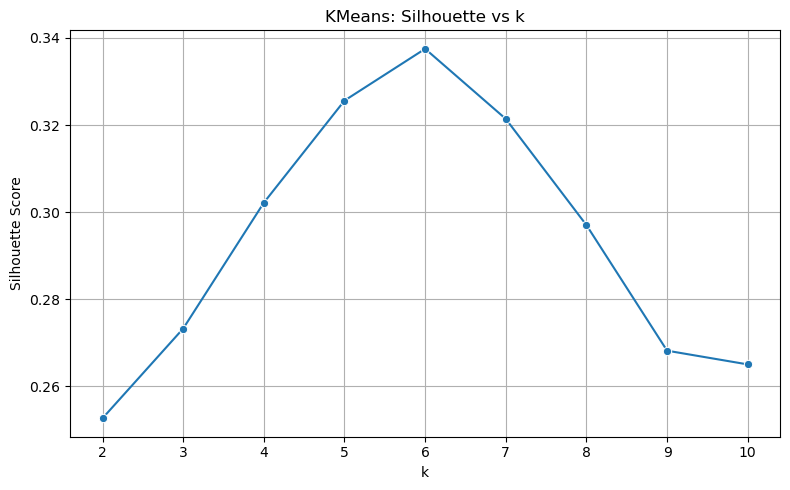

2025-12-02 22:47:34,062 INFO: Displayed silhouette vs k (KMeans)
c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\renat\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be remove

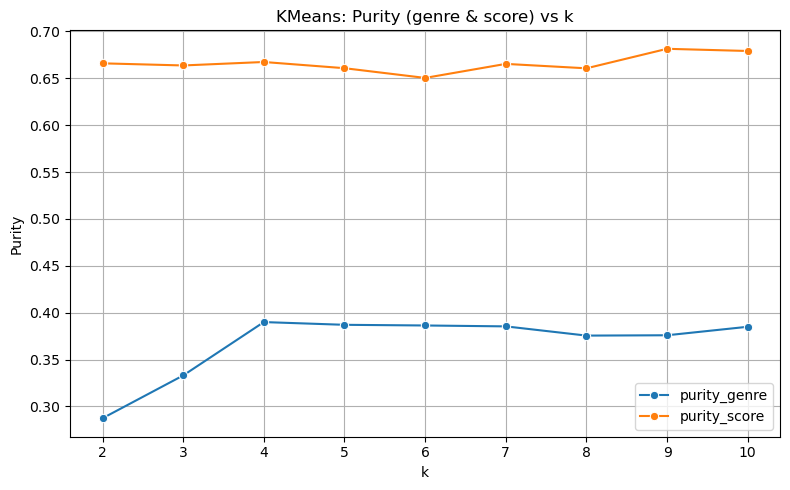

2025-12-02 22:47:34,248 INFO: Displayed purity vs k (KMeans)
2025-12-02 22:47:34,250 INFO: Best KMeans k by silhouette: 6
2025-12-02 22:47:34,250 INFO: Best KMeans k by silhouette: 6
2025-12-02 22:48:41,588 INFO: Projection method used: t-SNE
2025-12-02 22:48:41,588 INFO: Projection method used: t-SNE


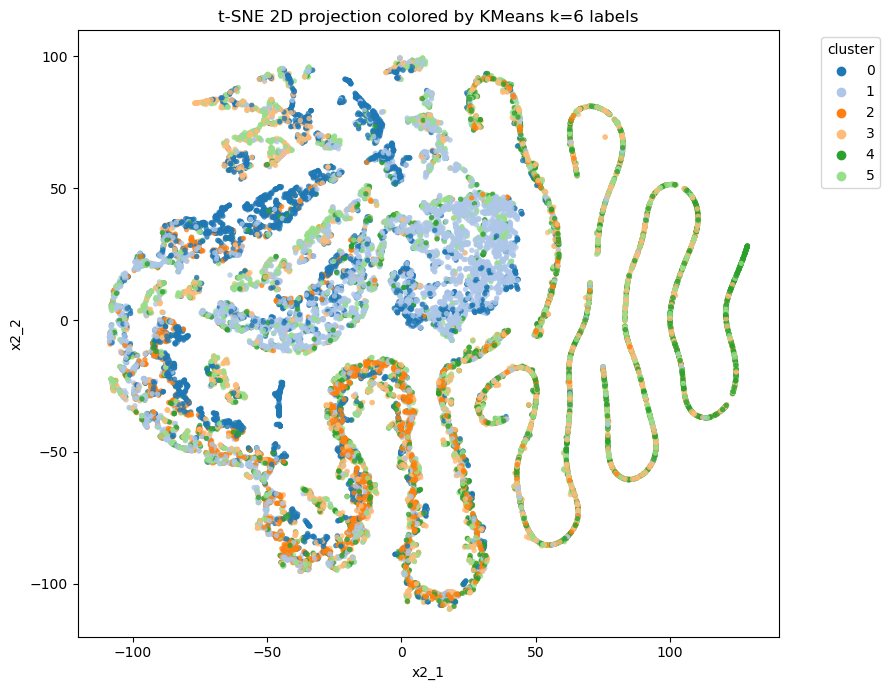

2025-12-02 22:48:42,007 INFO: Displayed 2D projection for KMeans k=6


<Figure size 1000x600 with 0 Axes>

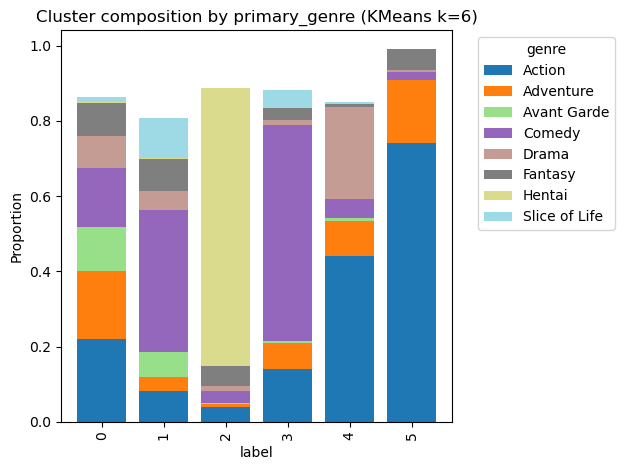

2025-12-02 22:48:42,249 INFO: Displayed cluster composition by primary_genre for k=6


<Figure size 800x500 with 0 Axes>

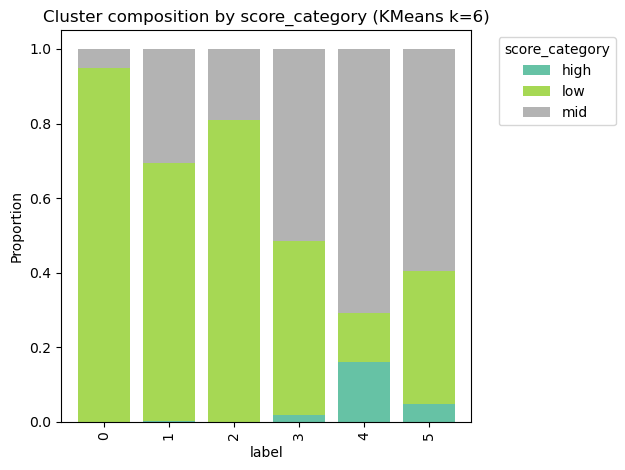

2025-12-02 22:48:43,229 INFO: Displayed cluster composition by score_category for k=6
2025-12-02 22:48:43,229 INFO: All visualization plots displayed (inline in the notebook)
2025-12-02 22:48:43,229 INFO: All visualization plots displayed (inline in the notebook)


In [25]:
"""
generate_visualizations.py

Carga `outputs/cluster_results.csv`, `outputs/merged_data.csv` y archivos de etiquetas (labels_kmeans_*.csv, labels_aggl_*.csv, labels_dbscan_*.csv)
Genera y muestra los gráficos inline en el notebook en lugar de guardarlos en disco.
Ejecución:
    Ejecutar esta celda en el notebook (no requiere llamada a script externo).
Dependencias: pandas, numpy, matplotlib, seaborn, scikit-learn, umap-learn (opcional)
"""

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

OUT = 'outputs'
PLOTS = os.path.join(OUT, 'plots')
os.makedirs(PLOTS, exist_ok=True)

# Cargar resultados
res_path = os.path.join(OUT, 'cluster_results.csv')
merged_path = os.path.join(OUT, 'merged_data.csv')
if not os.path.exists(res_path) or not os.path.exists(merged_path):
    logging.error('No se encuentran los archivos requeridos en outputs/. Ejecuta primero clustering_analysis.py')
    raise SystemExit(1)

res = pd.read_csv(res_path)
df = pd.read_csv(merged_path)

# Filtrar KMeans
km_res = res[res['method']=='kmeans'].copy()
km_res['k'] = km_res['params'].str.replace('k=','').astype(int)
km_res = km_res.sort_values('k')

# Plot silhouette vs k
plt.figure(figsize=(8,5))
sns.lineplot(data=km_res, x='k', y='silhouette', marker='o')
plt.title('KMeans: Silhouette vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()
logging.info('Displayed silhouette vs k (KMeans)')

# Plot purity (genre and score) vs k
plt.figure(figsize=(8,5))
sns.lineplot(data=km_res, x='k', y='pur_genre', marker='o', label='purity_genre')
sns.lineplot(data=km_res, x='k', y='pur_score', marker='o', label='purity_score')
plt.title('KMeans: Purity (genre & score) vs k')
plt.xlabel('k')
plt.ylabel('Purity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
logging.info('Displayed purity vs k (KMeans)')

# Elegir el k con mayor silhouette
best_row = km_res.loc[km_res['silhouette'].idxmax()]
best_k = int(best_row['k'])
logging.info('Best KMeans k by silhouette: %d', best_k)

# Cargar etiquetas correspondientes
labels_file = os.path.join(OUT, f'labels_kmeans_k{best_k}.csv')
if not os.path.exists(labels_file):
    logging.error('No se encuentra %s', labels_file)
    raise SystemExit(1)
labels = pd.read_csv(labels_file)

# Unir con df
# labels may contain animeID; df contains animeID
if 'animeID' in df.columns and 'animeID' in labels.columns:
    merged = pd.merge(df, labels, on='animeID', how='inner')
else:
    # fallback: use index
    labels = labels.rename(columns={labels.columns[0]:'animeID'})
    merged = pd.concat([df.reset_index(), labels['label']], axis=1)

# Proyección 2D: intentar UMAP, si no está disponible usar t-SNE o PCA
X_cols = [c for c in df.columns if c in ['score_num','episodes_num','year_num','rating_count','rating_mean','rating_std'] or c.startswith('type_') or c.startswith('genre_')]
X = merged[X_cols].fillna(0).values

try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X2 = reducer.fit_transform(X)
    method_used = 'UMAP'
except Exception:
    try:
        tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
        X2 = tsne.fit_transform(X)
        method_used = 't-SNE'
    except Exception:
        pca = PCA(n_components=2, random_state=42)
        X2 = pca.fit_transform(X)
        method_used = 'PCA'

logging.info('Projection method used: %s', method_used)
merged['x2_1'] = X2[:,0]
merged['x2_2'] = X2[:,1]

plt.figure(figsize=(9,7))
unique_labels = merged['label'].unique()
palette = sns.color_palette('tab20', n_colors=len(unique_labels))

sns.scatterplot(data=merged, x='x2_1', y='x2_2', hue='label', palette=palette, s=15, linewidth=0, alpha=0.8)
plt.title(f'{method_used} 2D projection colored by KMeans k={best_k} labels')
plt.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
logging.info('Displayed 2D projection for KMeans k=%d', best_k)

# Composición por género por cluster (usando primary_genre)
comp = merged.groupby(['label','primary_genre']).size().reset_index(name='count')
# calcular proporciones por cluster
total_per_cluster = comp.groupby('label')['count'].transform('sum')
comp['prop'] = comp['count'] / total_per_cluster

# Tomar top genres overall for plotting clarity
top_genres = merged['primary_genre'].value_counts().head(8).index.tolist()
comp_small = comp[comp['primary_genre'].isin(top_genres)]

plt.figure(figsize=(10,6))
# pivot for stacked bar
pv = comp_small.pivot(index='label', columns='primary_genre', values='prop').fillna(0)
pv.plot(kind='bar', stacked=True, colormap='tab20', width=0.8)
plt.ylabel('Proportion')
plt.title(f'Cluster composition by primary_genre (KMeans k={best_k})')
plt.legend(title='genre', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
logging.info('Displayed cluster composition by primary_genre for k=%d', best_k)

# Composición por score_category
if 'score_category' in merged.columns:
    comp2 = merged.groupby(['label','score_category']).size().reset_index(name='count')
    total_per_cluster2 = comp2.groupby('label')['count'].transform('sum')
    comp2['prop'] = comp2['count'] / total_per_cluster2
    pv2 = comp2.pivot(index='label', columns='score_category', values='prop').fillna(0)
    plt.figure(figsize=(8,5))
    pv2.plot(kind='bar', stacked=True, colormap='Set2', width=0.8)
    plt.ylabel('Proportion')
    plt.title(f'Cluster composition by score_category (KMeans k={best_k})')
    plt.legend(title='score_category', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()
    logging.info('Displayed cluster composition by score_category for k=%d', best_k)
else:
    logging.info('score_category no está disponible en merged_data.csv; omitiendo composición por score_category')

logging.info('All visualization plots displayed (inline in the notebook)')
